# **Labour Market Exploratory Data Analysis (EDA) Dashboard**

**Labour Market EDA Dashboard:** The primary objective of this project is to conduct a comprehensive Exploratory Data Analysis (EDA) on the Nigerian Labour Force Statistics dataset. The goal is to identify key trends, patterns, and anomalies,concerning employment, unemployment, and workforce composition  culminating in a visually compelling dashboard and a concise narrative summary that highlights critical insights for business leaders and policymakers.

## **Data Acquisition & Preprocessing**


In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Mounting my drive for file access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Dataset**

In [3]:
#Loading dataset
file_path='/content/drive/MyDrive/Caasitech Academy/AI Training Cameroon/Week 1/dataset_nlfs_2024q3_indiv.dta'
df=pd.read_stata(file_path)

In [4]:
#Create a copy of data set to manipulate
data=df.copy()
# Preview data
print(data.head())
print(data.shape)

  interview_key    id1_zone id2_state    id3_lga id4b_ea id5_sector  \
0   84-85-56-47  NORTH WEST    SOKOTO  GWADABAWA   46200      RURAL   
1   84-85-56-47  NORTH WEST    SOKOTO  GWADABAWA   46200      RURAL   
2   84-85-56-47  NORTH WEST    SOKOTO  GWADABAWA   46200      RURAL   
3   84-85-56-47  NORTH WEST    SOKOTO  GWADABAWA   46200      RURAL   
4   84-85-56-47  NORTH WEST    SOKOTO  GWADABAWA   46200      RURAL   

  id6_cluster  id7a_structure  id7_hhnumber  hhroster_id  ...  um13 um14 um15  \
0           1               2             1            1  ...   NaN  NaN  NaN   
1           1               2             1            2  ...   NaN  NaN  NaN   
2           1               2             1            3  ...   NaN  NaN  NaN   
3           1               2             1            4  ...   NaN  NaN  NaN   
4           1               2             1            5  ...   NaN  NaN  NaN   

  um15ots um16 um16ots       sample  eatarget iscoisicmerge interviewstartdate  
0    

### **Data Integrity Audit**

**1. Null Value & Datatype Analysis**

In [5]:
#Define some important columns to investigate
important_cols = [
    'id1_zone','id2_state', 'id3_lga',
    'id5_sector', #Urban or rural sector
    'dc3',  # gender
    'dc5',  # age
    'dc6',  # marital status
    'ed6',   # highest education level
    'ed7',    # highest qualification obtained
    'um1_1', 'um1_2',  # unemployment indicators
    'atw1', 'atw2', 'atw3',  # employment indicators
    'interviewdate',#date of survey
    'popw' #population weight rescaled
]
#Creating a data set copy with selected columns
im_data = data[important_cols]

#Renaming columns
im_data = im_data.rename(columns={
    'id1_zone': 'zone',
    'id2_state': 'state',
    'id3_lga': 'lga',
    'id5_sector': 'sector',
    'dc3': 'gender',
    'dc5': 'age',
    'dc6': 'marital_status',
    'um1_1': 'job_search',
    'um1_2': 'business_start',
    'atw1': 'worked_for_pay',
    'atw2': 'self_employed',
    'atw3': 'family_work',
    'ed6': 'education_level',
    'ed7': 'qualification'
})

#Check for datatypes
print (im_data.dtypes)

zone                     category
state                    category
lga                      category
sector                   category
gender                   category
age                          int8
marital_status           category
education_level          category
qualification            category
job_search               category
business_start           category
worked_for_pay           category
self_employed            category
family_work              category
interviewdate      datetime64[ns]
popw                      float32
dtype: object


In [6]:
#Check for columns with missing values amongst the identified important columns
important_missing = im_data.isnull().sum().sort_values(ascending=False)
print(important_missing)


job_search         27807
business_start     27803
family_work        23948
marital_status     15301
self_employed       9031
education_level     7511
qualification       7511
worked_for_pay      5955
gender                 0
age                    0
lga                    0
sector                 0
state                  0
zone                   0
interviewdate          0
popw                   0
dtype: int64


In [7]:
# Checking for the unique categories that exist in the columns with missing data (all categorical colums)
for col in ['job_search', 'business_start','worked_for_pay', 'self_employed', 'family_work','education_level','marital_status','qualification']:
    unique_values = im_data[col].unique()
    print(f"Unique values in {col}: {unique_values}")

Unique values in job_search: [NaN, 'NO', 'YES']
Categories (2, object): ['NO' < 'YES']
Unique values in business_start: [NaN, 'NO', 'YES']
Categories (2, object): ['NO' < 'YES']
Unique values in worked_for_pay: ['NO', NaN, 'YES']
Categories (2, object): ['YES' < 'NO']
Unique values in self_employed: ['YES', 'NO', NaN]
Categories (2, object): ['YES' < 'NO']
Unique values in family_work: [NaN, 'YES', 'NO']
Categories (2, object): ['YES' < 'NO']
Unique values in education_level: ['QUARANIC', NaN, 'P6', 'INTEGRATED ISLAMIC EDUCATION (ISLAMIYYA, TSAN..., 'NONE', ..., 'LOWER 6', 'BASIC LITERACY PROGRAM', 'TERTIARY VOCATIONAL/TECHNICAL/COMMERCIAL', 'UPPER 6', 'MODERN SCHOOL']
Length: 39
Categories (38, object): ['NONE' < 'N1' < 'N2' < 'PRE-NURSERY' < ... <
                          'UNIVERSITY - LEVELS 100, 200 OR 300' < 'UNIVERSITY - 400 LEVEL' < 'UNIVERSITY - 500 LEVEL' <
                          'UNIVERSITY - 600 LEVEL']
Unique values in marital_status: ['MARRIED (POLYGAMOUS)', 'NEVER MAR

In [8]:
# Dealing with missing values

# --- Unemployment related missing values  ---(assume values are missing because does not apply to person)
for col in ['job_search', 'business_start']:
    im_data[col] = im_data[col].fillna('NO')

# --- Employment related missing values ---(assume values are missing because does not apply to person)
for col in ['worked_for_pay', 'self_employed', 'family_work']:
    im_data[col] = im_data[col].fillna('NO')

# --- Education related missing values ---(Fill with unknown)
# Add 'Unknown' to categories before filling NaN
im_data['education_level'] = im_data['education_level'].cat.add_categories('Unknown')
im_data['education_level'] = im_data['education_level'].fillna('Unknown')

im_data['qualification'] = im_data['qualification'].cat.add_categories('Unknown')
im_data['qualification'] = im_data['qualification'].fillna('Unknown')

# --- Marital Status related missing values---(Fill with unknown)
im_data['marital_status'] = im_data['marital_status'].cat.add_categories('Unknown')
im_data['marital_status'] = im_data['marital_status'].fillna('Unknown')

In [9]:
#confirming no missing values
#Check for columns with missing values amongst the identified important columns
important_missing = im_data.isnull().sum().sort_values(ascending=False)
print(important_missing)
print (im_data.dtypes)

zone               0
state              0
lga                0
sector             0
gender             0
age                0
marital_status     0
education_level    0
qualification      0
job_search         0
business_start     0
worked_for_pay     0
self_employed      0
family_work        0
interviewdate      0
popw               0
dtype: int64
zone                     category
state                    category
lga                      category
sector                   category
gender                   category
age                          int8
marital_status           category
education_level          category
qualification            category
job_search               category
business_start           category
worked_for_pay           category
self_employed            category
family_work              category
interviewdate      datetime64[ns]
popw                      float32
dtype: object


**2. Duplicate Records**

In [10]:
#Check for duplicates in data
duplicates = im_data.duplicated().sum()
print("Duplicates:", duplicates)

#Drop duplicates from data
im_data = im_data.drop_duplicates()

Duplicates: 573


**3. Consistency Checks**

In [11]:
# AGE VALIDITY CHECK
# Age should be realistic (e.g., 0–100)
invalid_age = im_data[(im_data['age'] < 0) | (im_data['age'] > 100)]
print("Invalid age records:", len(invalid_age))


Invalid age records: 0


## **Exploratory Data Analysis(EDA)**

**1. Descriptive Statistics**

In [12]:
print(im_data[['age', 'popw']].describe())

                age          popw
count  43382.000000  43382.000000
mean      23.308285   4909.183105
std       18.844621   3787.138672
min        0.000000     70.734688
25%        8.000000   2369.335449
50%       18.000000   4007.452393
75%       35.000000   6305.146484
max      100.000000  37663.960938


**2. Distribution Analysis**

In [13]:
# Define employment status
def classify_status(row):
    if (row['worked_for_pay'] == 'YES') or (row['self_employed'] == 'YES') or (row['family_work'] == 'YES'):
        return 'Employed'
    elif (row['job_search'] == 'YES') or (row['business_start'] == 'YES'):
        return 'Unemployed'
    else:
        return 'Out of Labour Force'

im_data['employment_status'] = im_data.apply(classify_status, axis=1)

print(im_data['employment_status'].value_counts())

employment_status
Employed               23211
Out of Labour Force    19518
Unemployed               653
Name: count, dtype: int64


In [14]:
# DISTRIBUTION ANALYSIS (TABLES)

print("\n Gender Distribution:")
print(im_data['gender'].value_counts(normalize=True) * 100)

print("\n Sector Distribution (Urban vs Rural):")
print(im_data['sector'].value_counts(normalize=True) * 100)

print("\n Marital Status Distribution:")
print(im_data['marital_status'].value_counts(normalize=True) * 100)



 Gender Distribution:
gender
MALE      50.239731
FEMALE    49.760269
Name: proportion, dtype: float64

 Sector Distribution (Urban vs Rural):
sector
RURAL    50.656954
URBAN    49.343046
Name: proportion, dtype: float64

 Marital Status Distribution:
marital_status
Unknown                 34.348347
NEVER MARRIED           27.956295
MARRIED (MONOGAMOUS)    26.925914
MARRIED (POLYGAMOUS)     6.161542
WIDOWED                  3.185653
SEPARATED                0.822922
DIVORCED                 0.301969
INFORMAL/LOOSE UNION     0.297358
Name: proportion, dtype: float64


**3. Unemployment Trends**

In [15]:
# Unemployment by gender
unemp_gender = im_data[im_data['employment_status'] == 'Unemployed']['gender'].value_counts()
print("\n Unemployment by Gender:")
print(unemp_gender)

# Unemployment by sector
unemp_sector = im_data[im_data['employment_status'] == 'Unemployed']['sector'].value_counts()
print("\n Unemployment by Sector:")
print(unemp_sector)


 Unemployment by Gender:
gender
FEMALE    426
MALE      227
Name: count, dtype: int64

 Unemployment by Sector:
sector
URBAN    475
RURAL    178
Name: count, dtype: int64


**3. Top 10 States by Unemployment**

In [16]:
top_states = (
    im_data[im_data['employment_status'] == 'Unemployed']
    .groupby('state')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("\n Top 10 States by Unemployment:")
print(top_states)


 Top 10 States by Unemployment:
state
GOMBE     64
IMO       54
RIVERS    43
ONDO      37
OGUN      37
FCT       36
BORNO     32
ENUGU     28
BAUCHI    26
LAGOS     24
dtype: int64


/tmp/ipykernel_25642/1532113818.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('state')


 **4.Other Insights**

In [17]:
# Youth unemployment (age < 35)
youth_unemp = im_data[(im_data['age'] < 35) & (im_data['employment_status'] == 'Unemployed')]
print("Youth unemployment count:", len(youth_unemp))

# Education vs employment
top_states = (
    im_data[im_data['employment_status'] == 'Unemployed']
    .groupby('state')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("\n Top 10 States by Unemployment:")
print(top_states)

Youth unemployment count: 518

 Top 10 States by Unemployment:
state
GOMBE     64
IMO       54
RIVERS    43
ONDO      37
OGUN      37
FCT       36
BORNO     32
ENUGU     28
BAUCHI    26
LAGOS     24
dtype: int64


/tmp/ipykernel_25642/190876122.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('state')


## **Data Visualization**

In [26]:
#Create folder to save charts in
import os
os.makedirs('images', exist_ok=True)

/tmp/ipykernel_25642/3057348143.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=im_data, x='employment_status', palette='Set2')


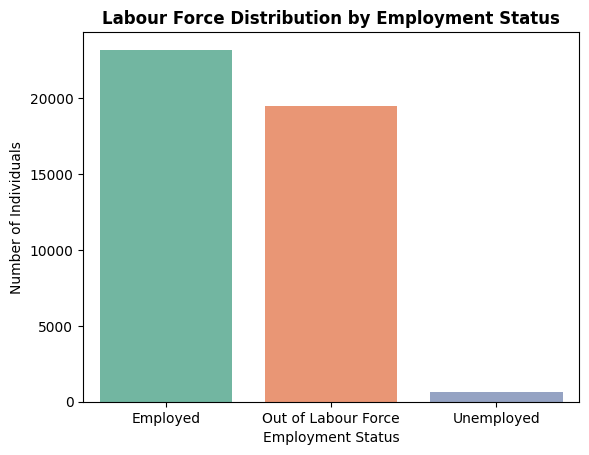

In [35]:
#1. Employment Status Distribution
sns.countplot(data=im_data, x='employment_status', palette='Set2')

plt.title("Labour Force Distribution by Employment Status", weight='bold')
plt.xlabel("Employment Status")
plt.ylabel("Number of Individuals")
plt.savefig('images/chart1_employment status distribution.png', dpi=300, bbox_inches='tight')

plt.show()

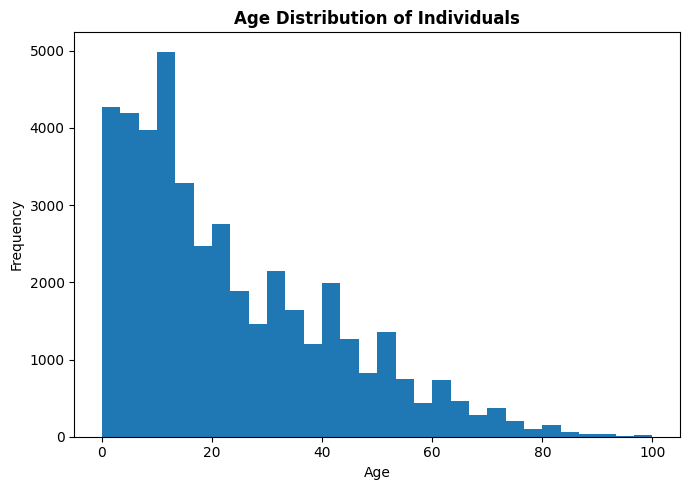

In [36]:
#2. Age distribution histogram
plt.figure(figsize=(7,5))
plt.hist(im_data['age'], bins=30)
plt.title('Age Distribution of Individuals', weight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/chart2_age distribution.png', dpi=300, bbox_inches='tight')
plt.show()

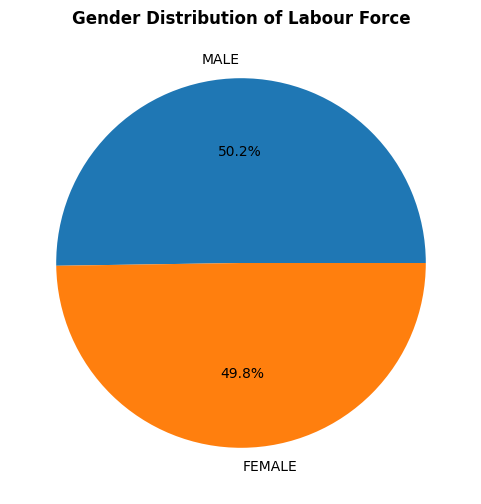

In [37]:
#3. Gender distribution
gender_counts = im_data['gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Gender Distribution of Labour Force', weight='bold')
plt.savefig('images/chart3_gender distribution.png', dpi=300, bbox_inches='tight')
plt.show()

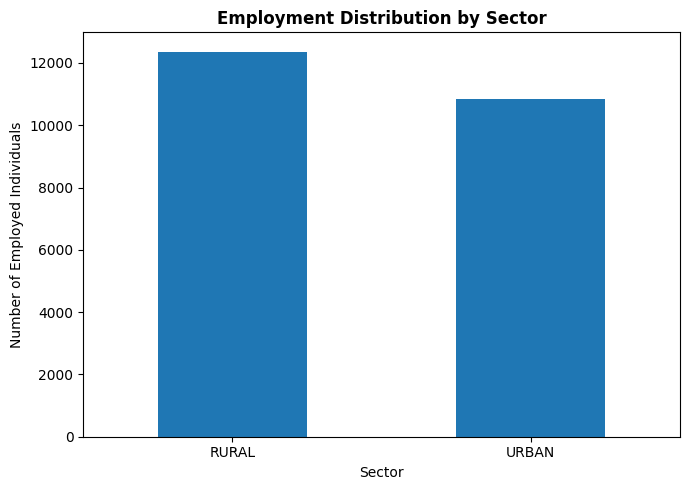

In [38]:
#Employment by sector
# Create employment indicator
im_data['is_employed'] = np.where(
    (im_data['worked_for_pay'] == 'YES') |
    (im_data['self_employed'] == 'YES') |
    (im_data['family_work'] == 'YES'),
    1, 0
)

employed_data = im_data[im_data['is_employed'] == 1]

employment_by_sector = employed_data['sector'].value_counts()

plt.figure(figsize=(7,5))
employment_by_sector.plot(kind='bar')
plt.title('Employment Distribution by Sector', weight='bold')
plt.xlabel('Sector')
plt.ylabel('Number of Employed Individuals')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/chart4_employment by sector.png', dpi=300, bbox_inches='tight')
plt.show()

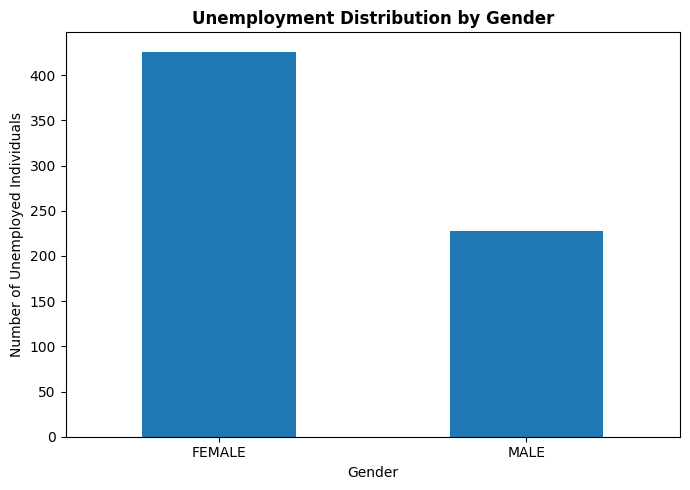

In [39]:
#Unemployment by gender
unemp_gender = im_data[im_data['employment_status'] == 'Unemployed']['gender'].value_counts()

plt.figure(figsize=(7,5))
unemp_gender.plot(kind='bar')
plt.title('Unemployment Distribution by Gender', weight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Unemployed Individuals')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/chart5_unemployment by gender.png', dpi=300, bbox_inches='tight')
plt.show()

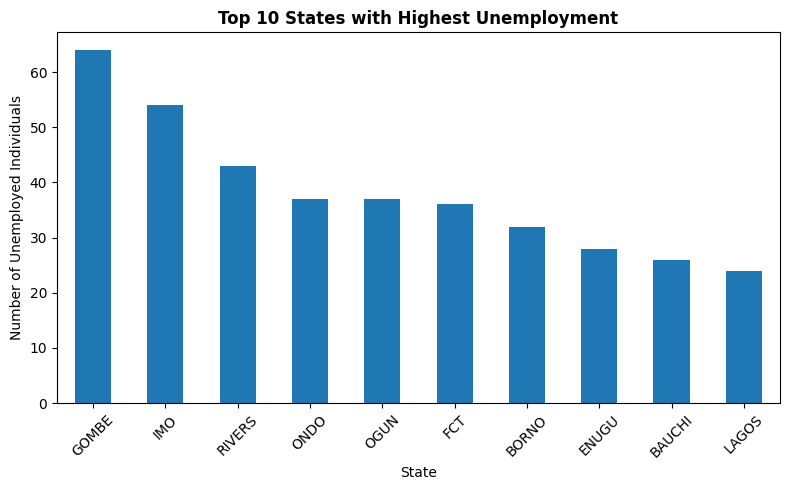

In [41]:
#Top 10 states by unemployment
top_states.plot(kind='bar', figsize=(8,5))
plt.title('Top 10 States with Highest Unemployment', weight='bold')
plt.xlabel('State')
plt.ylabel('Number of Unemployed Individuals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/chart6_top 10 states by unemployment.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1500x1000 with 0 Axes>

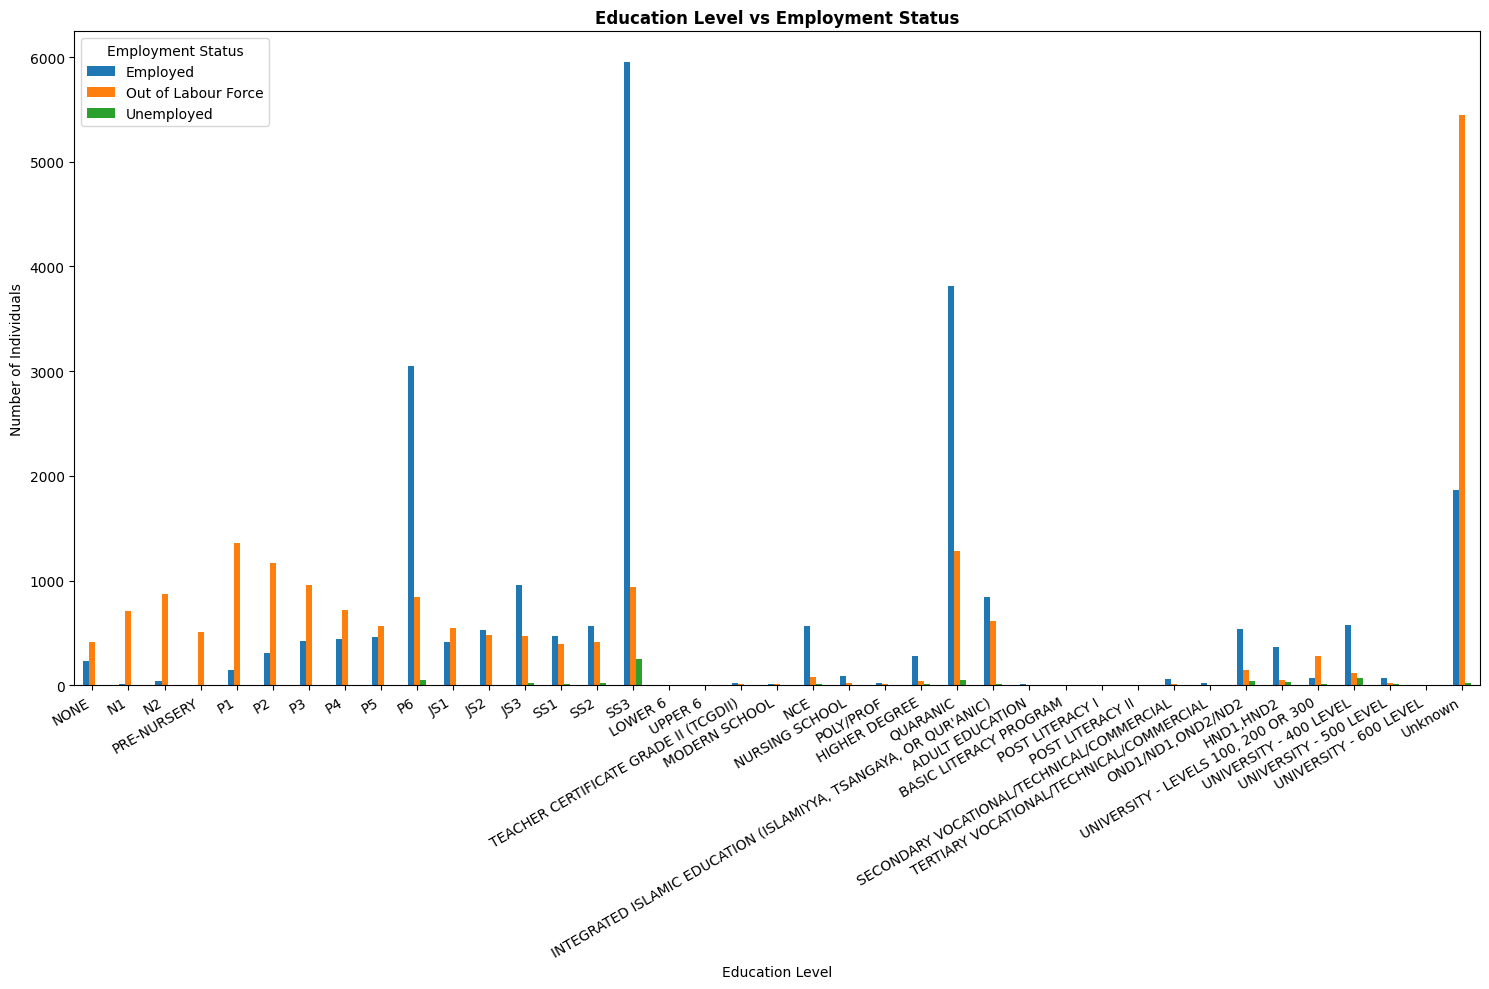

In [42]:
# Education level vs employment status
edu_emp = pd.crosstab(im_data['education_level'], im_data['employment_status'])

plt.figure(figsize=(15,10))
edu_emp.plot(kind='bar', figsize=(15,10))

plt.title('Education Level vs Employment Status', weight='bold')
plt.xlabel('Education Level')
plt.ylabel('Number of Individuals')

# Rotate x-axis labels and align to the right for better readability
plt.xticks(rotation=30, ha='right')

plt.legend(title='Employment Status')
plt.tight_layout()
plt.savefig('images/chart7_education level vs employment status.png', dpi=300, bbox_inches='tight')
plt.show()

employment_status  Employed  Out of Labour Force  Unemployed
age_group                                                   
0-14                   3075                14598          20
15-24                  5100                 2602         278
25-34                  4563                  567         220
35-44                  4458                  204          62
45-54                  3237                  119          41
55-64                  1680                  147          22
65+                    1098                  529          10


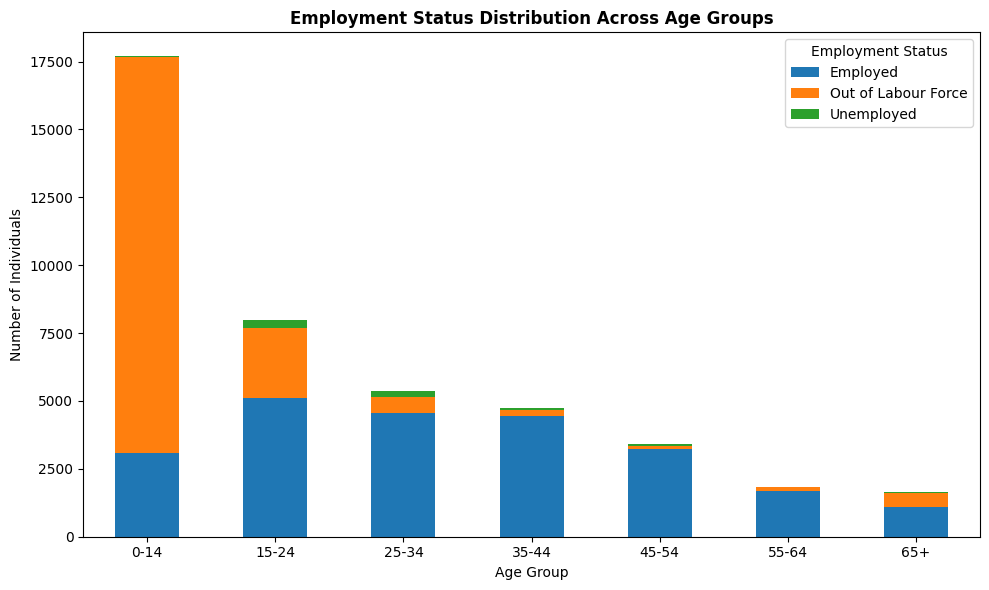

In [43]:
#Age group vs employment status
# Create age groups
bins = [0, 14, 24, 34, 44, 54, 64, 100]
labels = ['0-14', '15-24', '25-34', '35-44', '45-54', '55-64', '65+']

im_data['age_group'] = pd.cut(im_data['age'], bins=bins, labels=labels)

#Cross tabulation
age_emp = pd.crosstab(im_data['age_group'], im_data['employment_status'])
print(age_emp)

#Plot chart
age_emp.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Employment Status Distribution Across Age Groups', weight='bold')
plt.xlabel('Age Group')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=0)
plt.legend(title='Employment Status')
plt.tight_layout()
plt.savefig('images/chart8_age group vs employment status.png', dpi=300, bbox_inches='tight')
plt.show()

## **Narrative Sumary**

From the analysis of Nigeria’s labour force data, the following are three insights with important policy implications:

First, youth unemployment remains a significant challenge. A large proportion of unemployed individuals are under the age of 35, indicating difficulties in transitioning from education into stable employment. This suggests a need for stronger job creation initiatives, vocational training, and youth-focused employment programs.

Second, unemployment is notably higher in urban areas compared to rural areas. While cities are often seen as centers of opportunity, the data indicates increased competition for limited formal jobs. This raises concerns about urban job absorption capacity and highlights the importance of supporting small businesses and entrepreneurship in urban economies.

Third, there are clear regional disparities in unemployment levels, with certain states consistently showing higher unemployment rates. This suggests that economic opportunities are unevenly distributed across the country. Policymakers may need to adopt targeted, region-specific interventions to stimulate job creation and investment in high-unemployment areas.